In [1]:
from datasets import load_dataset
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt

#Load dataset

ds = load_dataset("UniqueData/messengers-reviews-google-play")

/Users/Kitu/anaconda3/envs/d266myassignment/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating train split: 100%|██████████| 6000/6000 [00:00<00:00, 94974.33 examples/s]


In [19]:
# ds = load_dataset("Mouwiya/drug-reviews")

# Convert to Pandas for exploration (train split only as example)
df = ds["train"].to_pandas()

In [23]:
df.columns

Index(['reviewId', 'userName', 'userImage', 'content', 'score',
       'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent',
       'repliedAt', 'appVersion', 'userLang', 'app_id'],
      dtype='object')

In [25]:
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,userLang,app_id
0,495266a4-f451-48c3-a844-fb3c07560d55,Foysal Hossain,https://play-lh.googleusercontent.com/a-/ALV-U...,Gett van for no reason 😂😂😂,1,0,None,2023-09-19 15:05:31,None,None,None,EN,org.telegram.messenger
1,947fcd83-7a28-403d-b03b-d0bc20f52e0e,S K VERMA,https://play-lh.googleusercontent.com/a/ACg8oc...,better' than WhatsApp,4,0,None,2023-09-19 14:59:30,None,None,None,EN,org.telegram.messenger
2,65856211-67ba-4560-84dd-a0055775ed90,Amanuel Abara,https://play-lh.googleusercontent.com/a/ACg8oc...,That was good app for me,5,0,None,2023-09-19 14:55:06,None,None,None,EN,org.telegram.messenger
3,cd5ba250-3a26-43b4-a378-77d18f73a503,Vagarangas X Aopi,https://play-lh.googleusercontent.com/a/ACg8oc...,Love the app,5,0,10.0.4,2023-09-19 14:50:18,None,None,10.0.4,EN,org.telegram.messenger
4,e8e886b4-d6c6-416b-b0a1-be90320c4024,Shafin islam,https://play-lh.googleusercontent.com/a-/ALV-U...,🕳️🕳️🕳️,1,0,None,2023-09-19 14:48:20,None,None,None,EN,org.telegram.messenger


In [27]:
df["score"].value_counts()

score
5    2745
1    1905
4     500
3     453
2     397
Name: count, dtype: int64

In [28]:
print("Not many data that we want! [Mark] Minimally 1,000 for each class, so we should find a dataset that’s already labeled Look out for class imbalance")

Not many data that we want! [Mark] Minimally 1,000 for each class, so we should find a dataset that’s already labeled Look out for class imbalance


Class distribution:
 rating_bucket
bad         953
nuetral    2745
worse      2302
Name: count, dtype: int64


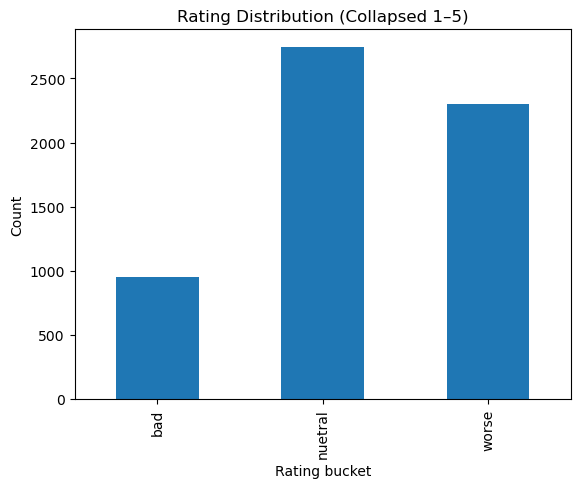


Balanced class distribution:
 rating_bucket
bad        953
nuetral    953
worse      953
Name: count, dtype: int64


/var/folders/gj/bbgjz4_x5ybc58ms5zv9p8sr0000gp/T/ipykernel_71596/3448341835.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_df = df.groupby("rating_bucket", group_keys=False).apply(


In [ ]:



# Collapse rating 1–10 → 1–5 buckets
def collapse_rating(r):
    if r in [1, 2]:
        return "worse"
    elif r in [3, 4]:
        return "bad"
    elif r in [5, 6]:
        return "nuetral"
    elif r in [7, 8]:
        return "good"
    elif r in [9, 10]:
        return "best"


df["rating_bucket"] = df["score"].apply(collapse_rating)

# Check distribution (imbalance)
rating_counts = df["rating_bucket"].value_counts().sort_index()
print("Class distribution:\n", rating_counts)

# visualize the distribution
rating_counts.plot(kind="bar", title="Rating Distribution (Collapsed 1–5)")
plt.xlabel("Rating bucket")
plt.ylabel("Count")
plt.show()

# Balance dataset (undersample the majority class for demonstration)
min_count = rating_counts.min()
balanced_df = df.groupby("rating_bucket", group_keys=False).apply(
    lambda x: x.sample(min_count, random_state=42)
)

print("\nBalanced class distribution:\n", balanced_df["rating_bucket"].value_counts())